In [1]:
# Python for GIS - Geopandas (I)
# Our tutorial: https://gist.github.com/jorisvandenbossche/7b30ed43366a85af8626
#
# %matplotlib is a magic function in IPython. I'll quote the relevant documentation here for you to read for convenience:
# IPython has a set of predefined ‘magic functions’ that you can call with a command line style syntax. There are two kinds of magics, line-oriented and cell-oriented. Line magics are prefixed with the % character and work much like OS command-line calls: they get as an argument the rest of the line, where arguments are passed without parentheses or quotes. Lines magics can return results and can be used in the right hand side of an assignment. Cell magics are prefixed with a double %%, and they are functions that get as an argument not only the rest of the line, but also the lines below it in a separate argument.
# "%matplotlib inline" sets the backend of matplotlib to the 'inline' backend, so the output of plotting commands is displayed inline within frontends like the Jupyter notebook, directly below the code cell that produced it. The resulting plots will then also be stored in the notebook document.

In [1]:
%matplotlib inline

In [2]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install earthpy

Note: you may need to restart the kernel to use updated packages.


In [71]:
#Comments: my python do not contain geopandas and earthpy, therefore use pip install to install them.

In [2]:
import geopandas

In [3]:
import pandas as pd

In [4]:
pd.options.display.max_rows = 4

In [5]:
from matplotlib import pyplot as plt

In [6]:
# Import earthpy to use for reprojecting data; conda install -c conda-forge earthpy see https://pypi.org/project/earthpy/

In [7]:
import earthpy as et

In [8]:
# use downloaded shp data from Blackboard or from original source: http://www.eea.europa.eu/data-and-maps/data/urban-atlas
# we are using the older version of the data, and example data for Antwerp, which works works with our tutorial: https://gist.github.com/jorisvandenbossche/7b30ed43366a85af8626

In [9]:
data = geopandas.read_file("../project3/landuse.shp")

In [10]:
# Identify the coordinate system
print(data.crs)

epsg:31370


In [11]:
data

,CITIES,LUZ_OR_CIT,CODE,ITEM,PROD_DATE,SHAPE_LEN,SHAPE_AREA,geometry
0,Antwerpen,BE002L,11230,Discontinuous Low Density Urban Fabric (S.L. :...,2009,6.447215e+02,2.592345e+04,"POLYGON ((161969.855 241216.924, 161862.493 24..."
1,Antwerpen,BE002L,12220,Other roads and associated land,2009,8.223079e+06,3.416457e+07,"POLYGON ((161231.896 240628.018, 161222.220 24..."
...,...,...,...,...,...,...,...,...
16979,Antwerpen,BE002L,50000,Water bodies,2009,1.386258e+03,2.241820e+04,"POLYGON ((155583.502 195764.771, 155606.557 19..."
16980,Antwerpen,BE002L,50000,Water bodies,2009,9.981053e+02,1.567485e+04,"POLYGON ((157205.193 195857.186, 157221.583 19..."


In [13]:
data.crs

<Derived Projected CRS: EPSG:31370>
Name: BD72 / Belgian Lambert 72
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Belgium - onshore.
- bounds: (2.5, 49.5, 6.4, 51.51)
Coordinate Operation:
- name: Belgian Lambert 72
- method: Lambert Conic Conformal (2SP)
Datum: Reseau National Belge 1972
- Ellipsoid: International 1924
- Prime Meridian: Greenwich

In [16]:
print(data)


          CITIES LUZ_OR_CIT   CODE  \
1      Antwerpen     BE002L  12220   
2      Antwerpen     BE002L  11230   
...          ...        ...    ...   
16979  Antwerpen     BE002L  50000   
16980  Antwerpen     BE002L  50000   

                                                    ITEM PROD_DATE  \
1                        Other roads and associated land      2009   
2      Discontinuous Low Density Urban Fabric (S.L. :...      2009   
...                                                  ...       ...   
16979                                       Water bodies      2009   
16980                                       Water bodies      2009   

          SHAPE_LEN    SHAPE_AREA  \
1      8.223079e+06  3.416457e+07   
2      2.737507e+02  2.297339e+03   
...             ...           ...   
16979  1.386258e+03  2.241820e+04   
16980  9.981053e+02  1.567485e+04   

                                                geometry  
1      POLYGON ((161231.896 240628.018, 161222.220 24...  
2      PO

In [14]:
data = data.drop(0)

In [15]:
data.head(3)

,CITIES,LUZ_OR_CIT,CODE,ITEM,PROD_DATE,SHAPE_LEN,SHAPE_AREA,geometry
1,Antwerpen,BE002L,12220,Other roads and associated land,2009,8.223079e+06,3.416457e+07,"POLYGON ((161231.896 240628.018, 161222.220 24..."
2,Antwerpen,BE002L,11230,Discontinuous Low Density Urban Fabric (S.L. :...,2009,2.737507e+02,2.297339e+03,"POLYGON ((161767.009 241277.756, 161767.480 24..."
3,Antwerpen,BE002L,30000,Forests,2009,4.402571e+03,3.656241e+05,"POLYGON ((161767.009 241277.756, 161745.219 24..."


In [13]:
# Calculate the area of each polygon:

In [19]:
data.geometry.area

1        3.418716e+07
2        2.299096e+03
             ...     
16979    2.243158e+04
16980    1.568410e+04
Length: 16980, dtype: float64

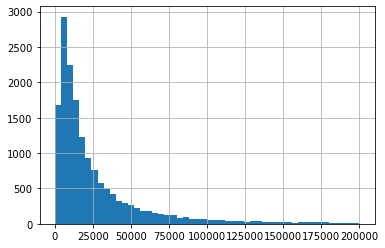

In [20]:
data.geometry.area.hist(bins=50, range=(0,0.2e6))

In [21]:
# Plot the shapes with coloring based on anohter column

In [22]:
bounds = data.bounds
bounds

,minx,miny,maxx,maxy
1,141781.493728,195674.470312,176199.833567,241374.894822
2,161767.008795,241277.756217,161843.013222,241373.354296
...,...,...,...,...
16979,155399.888716,195672.890896,155957.076617,195955.561741
16980,156757.127601,195780.210344,157221.582914,195907.025499


In [23]:
data = data[((bounds['minx'] < 160000) & (bounds['maxx'] > 150000) & (bounds['miny'] < 215000) & (bounds['maxy'] > 208000))]

In [24]:
data = data[data['ITEM'] != 'Water bodies']

In [26]:
pip install descartes

Note: you may need to restart the kernel to use updated packages.


In [27]:
# Import descartes to use for plotting polygons in geopandas
import descartes

(208000.0, 215000.0)

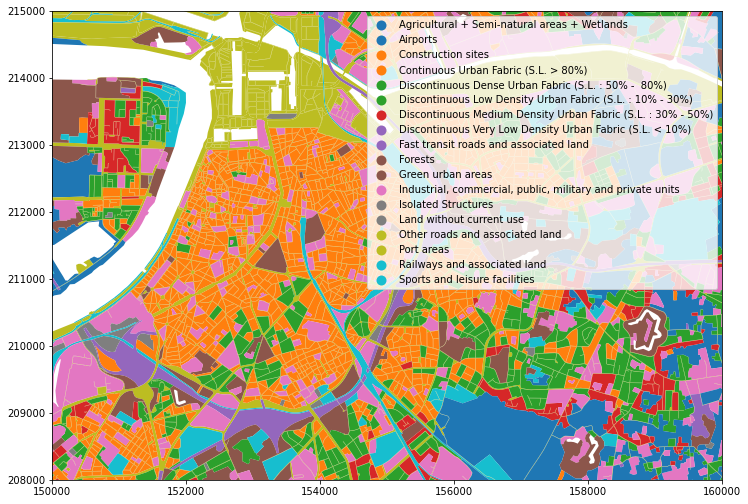

In [36]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
data.plot(column='ITEM', legend=True, ax=ax)
ax.set_xlim(150000, 160000)
ax.set_ylim(208000, 215000)

In [37]:
green_areas = data[data['ITEM']=='Green urban areas']

In [14]:
streets = geopandas.read_file("../project3/layer_streets.shp")

,ST_NAME,geometry
0,WILRIJK,"LINESTRING (152579.892 208950.179, 152237.929 ..."
1,VILLERSLEI,"LINESTRING (161028.443 215901.418, 161171.291 ..."
...,...,...
22489,SINT-FREDEGANDUSSTRAAT,"LINESTRING (156443.455 213182.348, 156450.405 ..."
22490,JULES MORETUSLEI,"LINESTRING (151525.552 206928.285, 151706.687 ..."


In [39]:
strs = (streets.crs) 
print(streets.crs)

epsg:31370


In [40]:
# To display these together, or perform a spatial analysis, do any layers need to be reprojected?...i.e. see https://www.earthdatascience.org/workshops/gis-open-source-python/reproject-vector-data-in-python/

In [41]:
# view the spatial extent of both layers 
print(data.total_bounds)
print(streets.total_bounds)

[141781.49372781 195674.47031193 176199.83356685 241374.89482236]
[141709.72170266 203857.67930245 163720.86294721 223753.51469011]


In [42]:
# reproject the streets layer i.e. using the EPSG code? If they are the same projection, you don't need to reproject one.
# streets_reprojected  = data.to_crs({'init': 'epsg:3035'}) # still works but give a warning; see https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6 - can you fix it?

In [43]:
# view the spatial extent of both layers again 
print(data.total_bounds)
# print(streets_reprojected.total_bounds)

[141781.49372781 195674.47031193 176199.83356685 241374.89482236]


(208000.0, 215000.0)

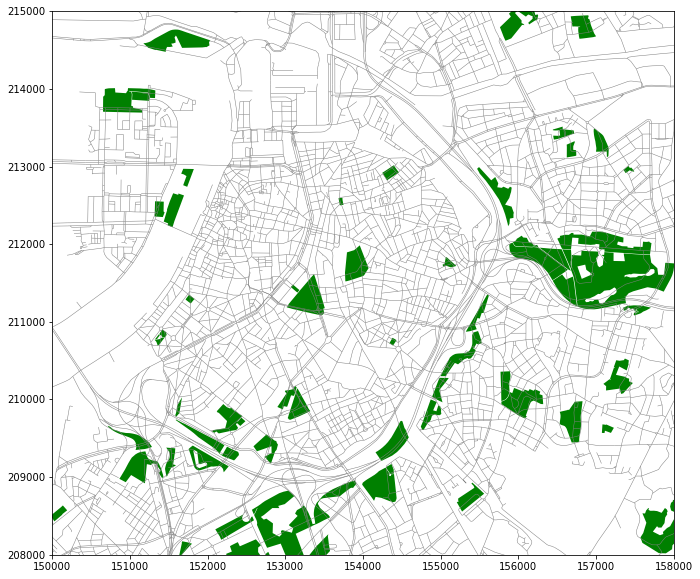

In [44]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
green_areas.plot(ax=ax, color='green')
ax.set_xlim(150000, 158000)
ax.set_ylim(208000, 215000)

(208000.0, 215000.0)

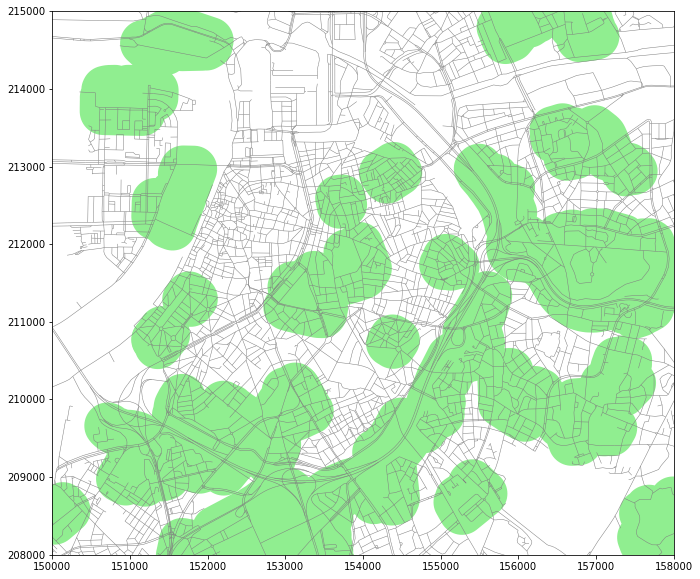

In [45]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
green_areas.geometry.buffer(300).plot(ax=ax, color='lightgreen')
ax.set_xlim(150000, 158000)
ax.set_ylim(208000, 215000)

In [16]:
addresses = geopandas.read_file("../project3/CRAB_subset.shp")

In [49]:
print(addresses.crs)

epsg:31370


In [50]:
# view the spatial extent of all 3 layers 
print(data.total_bounds)
print(streets.total_bounds)
print(addresses.total_bounds)

[141781.49372781 195674.47031193 176199.83356685 241374.89482236]
[141709.72170266 203857.67930245 163720.86294721 223753.51469011]
[150983.43044025 208801.66634058 156024.30044036 214061.0263407 ]


In [51]:
# do you need to reproject the addresses to match the streets layers ? ...i.e. using the EPSG code; still works but gives a warning - can you fix it?
# addresses_reprojected  = data.to_crs({'init': 'epsg:3035'})

In [52]:
# view the spatial extent of all 3 layers 
print(data.total_bounds)
print(streets.total_bounds)
print(addresses.total_bounds)

[141781.49372781 195674.47031193 176199.83356685 241374.89482236]
[141709.72170266 203857.67930245 163720.86294721 223753.51469011]
[150983.43044025 208801.66634058 156024.30044036 214061.0263407 ]


In [53]:
x = addresses.geometry.apply(lambda p: p.x)
y = addresses.geometry.apply(lambda p: p.y)
print(x,y)

0        153489.27044
1        153388.82044
             ...     
56039    154319.81044
56040    151301.89044
Name: geometry, Length: 56041, dtype: float64 0        210071.496341
1        210911.296341
             ...      
56039    211782.986341
56040    210677.107341
Name: geometry, Length: 56041, dtype: float64


In [54]:
addresses = addresses[(x < 156000).values & (x > 152000) .values & (y < 213000) .values & (y > 210000) .values]

(210000.0, 213000.0)

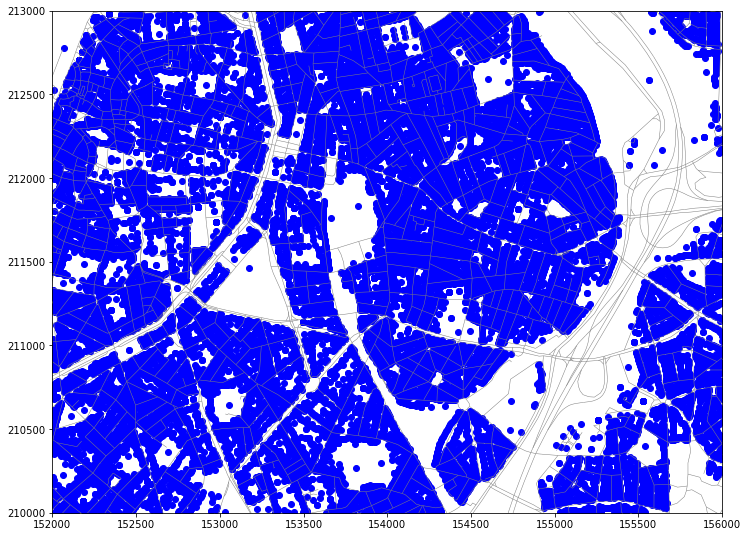

In [63]:
fig, ax = plt.subplots(figsize=(12,10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
addresses.plot(ax=ax, color='blue')
ax.set_xlim(152000, 156000)
ax.set_ylim(210000, 213000)

In [64]:
# Question: what is the distance to the nearest green area for all adresses?

In [65]:
urban_green = data[(data['ITEM']=='Green urban areas') & (data.geometry.area > 10000)]

In [66]:
def urban_green_dist(point, urban_green):
    return urban_green.geometry.distance(point).min()

In [67]:
min_distance = addresses.geometry.apply(lambda x: urban_green_dist(x, urban_green))

In [68]:
addresses['min_distance'] = min_distance

/opt/anaconda3/lib/python3.8/site-packages/geopandas/plotting.py:630: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  warnings.warn(


(210000.0, 213000.0)

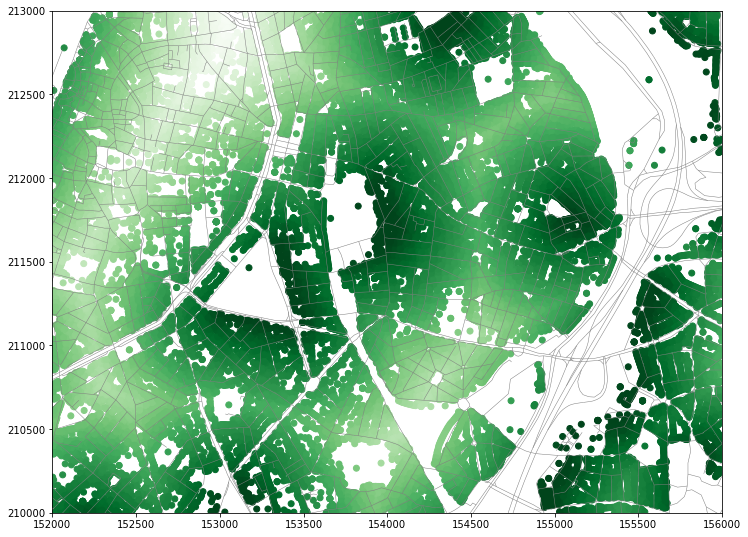

In [69]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'aspect':'equal'})
streets.plot(ax=ax, color="grey", linewidth=0.5)
addresses.plot(ax=ax, column='min_distance', colormap='Greens_r')
ax.set_xlim(152000, 156000)
ax.set_ylim(210000, 213000)

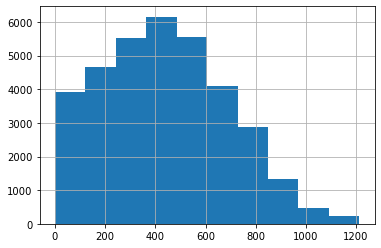

In [70]:
addresses['min_distance'].hist()